In [2]:
import pickle
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import paper_style  # apply the style automatically
import gc
import psutil
import yaml
import sys
import torch
import io
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




# Input Config

In [3]:
df = pd.read_csv('/home/evrond/rl_for_curobo_analysis/projects_root/experiments/armsResults_date1409_rows960_rowTypeTrial.csv')
df

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val
0,2025-09-08_03:30:27_R_ur5e_N4_AO_Tbin_s5_l2,"O(400, 1)",bin,2,5,0.000,6.000000
1,2025-09-08_04:01:24_R_ur5e_N4_AO_Tbin_s3_l4,"O(400, 1)",bin,4,3,0.022,7.000000
2,2025-09-08_03:27:28_R_ur5e_N4_AO_Tbin_s4_l2,"O(400, 1)",bin,2,4,0.000,6.000000
3,2025-09-08_04:23:09_R_ur5e_N4_AO_Tbin_s4_l5,"O(400, 1)",bin,5,4,0.000,8.000000
4,2025-09-08_04:04:41_R_ur5e_N4_AO_Tbin_s4_l4,"O(400, 1)",bin,4,4,0.000,6.000000
...,...,...,...,...,...,...,...
955,2025-09-08_22:54:49_R_ur5e_N4_ACC_Tfollow_s5_l2,CC(500),follow,2,5,0.000,0.304553
956,2025-09-08_22:41:53_R_ur5e_N4_ACC_Tfollow_s2_l2,CC(500),follow,2,2,0.000,0.297082
957,2025-09-08_22:22:11_R_ur5e_N4_ACC_Tfollow_s3_l1,CC(500),follow,1,3,0.000,0.310030
958,2025-09-08_23:40:16_R_ur5e_N4_ACC_Tfollow_s3_l4,CC(500),follow,4,3,0.278,0.307996


In [4]:
def normalize(df, baseline_alg='O(400, 5)', normalization_type='diff_from_baseline',add_baseline_raw_vals=True):
    """
    normalization_type: "diff_from_baseline" or "ratio_from_max"
        diff_from_baseline: normalized_task_val = task_val - baseline_alg's task_val at the same (task_type, task_seed, task_level)
        ratio_from_max: normalized_task_val = task_val / max task_val over all algs at the same(task_type, task_seed, task_level)
    
    """
    
    df_work = df.copy()
    df_work['normalized_task_val'] = 0.0
    df_work['normalized_col_chance'] = 0.0
    if add_baseline_raw_vals:
        df_work['baseline_task_val'] = 0.0
        df_work['baseline_col_chance'] = 0.0
    
    # Get all unique combinations of task_type, task_seed, task_level
    unique_combinations = df_work[['task_type', 'task_seed', 'task_level']].drop_duplicates() # df with all unique combinations of task_type, task_seed, task_level, each appears only once
    
    for idx, row in unique_combinations.iterrows():
        # print(idx, row)
        task_type = row['task_type']
        task_seed = row['task_seed'] 
        task_level = row['task_level']
        
        # Find the baseline_alg rows with matching task_type, task_seed, task_level
        baseline_alg_mask = (
            (df_work['alg'] == baseline_alg) & 
            (df_work['task_type'] == task_type) & 
            (df_work['task_seed'] == task_seed) & 
            (df_work['task_level'] == task_level)
        )
        
        baseline_alg_rows = df_work[baseline_alg_mask]
        
        # Sanity check: verify there is exactly one baseline_alg row
        if len(baseline_alg_rows) == 0:
            raise ValueError(f"No {baseline_alg} row found for task_type={task_type}, "
                           f"task_seed={task_seed}, task_level={task_level}")
        elif len(baseline_alg_rows) > 1:
            raise ValueError(f"Multiple {baseline_alg} rows found for task_type={task_type}, "
                           f"task_seed={task_seed}, task_level={task_level}. Found {len(baseline_alg_rows)} rows.")
        
        # Get the baseline_alg task_val
        baseline_alg_task_val = baseline_alg_rows['task_val'].iloc[0]
        baseline_alg_col_chance = baseline_alg_rows['col_chance'].iloc[0]
        
            
        # Compute deviation for all rows with this combination
        combination_mask = (
            (df_work['task_type'] == task_type) & 
            (df_work['task_seed'] == task_seed) & 
            (df_work['task_level'] == task_level)
        )
        
        if normalization_type == 'diff_from_baseline':
            # normalize task_val - diff from baseline
            df_work.loc[combination_mask, 'normalized_task_val'] = (
                    df_work.loc[combination_mask, 'task_val'] - baseline_alg_task_val
                )
            

            # normalize col_chance - diff from baseline
            df_work.loc[combination_mask, 'normalized_col_chance'] = (
                    df_work.loc[combination_mask, 'col_chance'] - baseline_alg_col_chance
                )
            
        elif normalization_type == 'ratio_from_max':

            # normalize task_val - ratio from max
            max_task_val = df_work.loc[combination_mask, 'task_val'].max()
            if max_task_val == 0:
                normalized_ratio = 1 # avoid division by zero
            else:  
                normalized_ratio = df_work.loc[combination_mask, 'task_val'] / max_task_val  
            df_work.loc[combination_mask, 'normalized_task_val'] = normalized_ratio
            
            # normalize col_chance - ratio from max
            max_col_chance = df_work.loc[combination_mask, 'col_chance'].max()
            if max_col_chance == 0:
                normalized_col_chance = 1 # avoid division by zero
            else:  
                normalized_col_chance = df_work.loc[combination_mask, 'col_chance'] / max_col_chance
            df_work.loc[combination_mask, 'normalized_col_chance'] = normalized_col_chance
            
        if add_baseline_raw_vals:
            df_work.loc[combination_mask, 'baseline_task_val'] = baseline_alg_task_val
            df_work.loc[combination_mask, 'baseline_col_chance'] = baseline_alg_col_chance
                
    return df_work

In [5]:
df_normalized_diff_from_O400_5 = normalize(df)
df_normalized_ratio_from_max = normalize(df, normalization_type='ratio_from_max')




In [6]:
df_normalized_diff_from_O400_5

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val,normalized_task_val,normalized_col_chance,baseline_task_val,baseline_col_chance
0,2025-09-08_03:30:27_R_ur5e_N4_AO_Tbin_s5_l2,"O(400, 1)",bin,2,5,0.000,6.000000,1.000000,0.000,5.000000,0.000
1,2025-09-08_04:01:24_R_ur5e_N4_AO_Tbin_s3_l4,"O(400, 1)",bin,4,3,0.022,7.000000,0.000000,0.022,7.000000,0.000
2,2025-09-08_03:27:28_R_ur5e_N4_AO_Tbin_s4_l2,"O(400, 1)",bin,2,4,0.000,6.000000,-2.000000,0.000,8.000000,0.000
3,2025-09-08_04:23:09_R_ur5e_N4_AO_Tbin_s4_l5,"O(400, 1)",bin,5,4,0.000,8.000000,-1.000000,0.000,9.000000,0.000
4,2025-09-08_04:04:41_R_ur5e_N4_AO_Tbin_s4_l4,"O(400, 1)",bin,4,4,0.000,6.000000,-1.000000,0.000,7.000000,0.000
...,...,...,...,...,...,...,...,...,...,...,...
955,2025-09-08_22:54:49_R_ur5e_N4_ACC_Tfollow_s5_l2,CC(500),follow,2,5,0.000,0.304553,0.208860,0.000,0.095693,0.000
956,2025-09-08_22:41:53_R_ur5e_N4_ACC_Tfollow_s2_l2,CC(500),follow,2,2,0.000,0.297082,0.181914,0.000,0.115167,0.000
957,2025-09-08_22:22:11_R_ur5e_N4_ACC_Tfollow_s3_l1,CC(500),follow,1,3,0.000,0.310030,0.216714,0.000,0.093316,0.000
958,2025-09-08_23:40:16_R_ur5e_N4_ACC_Tfollow_s3_l4,CC(500),follow,4,3,0.278,0.307996,0.202744,0.278,0.105252,0.000


In [7]:
# df_normalized_diff_from_O400_5_gb_task = df_normalized_diff_from_O400_5.groupby(['task_type'])
# df_normalized_diff_from_O400_5_gb_task_and_level = df_normalized_diff_from_O400_5.groupby(['task_type', 'task_level'])


In [8]:
def compute_algorithm_statistics(df, group_keys):
    """
    Compute mean and standard deviation statistics for each algorithm within groups.
    
    Groups the dataframe by the specified keys, then further groups by 'alg' within each group,
    and computes mean and std for normalized_task_val and normalized_col_chance.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data with columns: 'alg', 'normalized_task_val', 'normalized_col_chance'
        and the grouping keys
    group_keys : list
        List of column names to group by (e.g., ['task_type', 'task_level'])
        
    Returns:
    --------
    pandas.DataFrame
        Summary table with columns:
        - All group_keys columns
        - 'alg' column
        - 'normalized_task_val_mean', 'normalized_task_val_std'
        - 'normalized_col_chance_mean', 'normalized_col_chance_std'
        - 'count' (number of rows for each algorithm-group combination)
    """
    # Group by the specified keys and 'alg'
    grouped = df.groupby(group_keys + ['alg'])
    
    
    if not 'baseline_task_val' in df.columns and not 'baseline_col_chance' in df.columns:
        # Compute statistics for each group
        stats = grouped.agg({
            'normalized_task_val': ['mean', 'std'],
            'normalized_col_chance': ['mean', 'std'],
            'sim_id': 'count'  # Count number of rows
        }).round(3)
        
        # Flatten column names
        stats.columns = [
            'normalized_task_val_mean', 'normalized_task_val_std',
            'normalized_col_chance_mean', 'normalized_col_chance_std',
            'count'
        ]
    else:
        stats = grouped.agg({
            'normalized_task_val': ['mean', 'std'],
            'normalized_col_chance': ['mean', 'std'],
            'baseline_task_val': ['mean', 'std'],
            'baseline_col_chance': ['mean', 'std'],
            'sim_id': 'count'  # Count number of rows
        }).round(3)
        stats.columns = [
            'normalized_task_val_mean', 'normalized_task_val_std',
            'normalized_col_chance_mean', 'normalized_col_chance_std',
            'baseline_task_val_mean', 'baseline_task_val_std',
            'baseline_col_chance_mean','baseline_col_chance_std',
            'count'
        ]
    # Reset index to make group_keys and 'alg' regular columns
    stats = stats.reset_index()
    
    return stats

In [9]:
# Group by task_type and task_level
result = compute_algorithm_statistics(df_normalized_diff_from_O400_5, ['task_type'])
# result.to_csv('df_normalized_diff_from_O400_5_grouped_by_task_baseline_raw_vals.csv', index=False)

In [10]:
result

,task_type,alg,normalized_task_val_mean,normalized_task_val_std,normalized_col_chance_mean,normalized_col_chance_std,baseline_task_val_mean,baseline_task_val_std,baseline_col_chance_mean,baseline_col_chance_std,count
0,bin,CC(1000),-6.033,3.146,0.010,0.075,6.500,2.596,0.004,0.011,30
1,bin,CC(500),-6.000,3.118,-0.004,0.011,6.500,2.596,0.004,0.011,30
2,bin,"O(400, 1)",-0.733,2.083,0.004,0.016,6.500,2.596,0.004,0.011,30
3,bin,"O(400, 5)",0.000,0.000,0.000,0.000,6.500,2.596,0.004,0.011,30
4,bin,"O-(400, 5)",-3.867,3.739,0.027,0.041,6.500,2.596,0.004,0.011,30
5,bin,"SC(1600, 5)",-2.167,3.119,0.080,0.080,6.500,2.596,0.004,0.011,30
6,bin,"SC(400, 5)",-4.733,2.638,0.045,0.055,6.500,2.596,0.004,0.011,30
7,bin,"SD(400, 5)",0.433,2.944,0.229,0.277,6.500,2.596,0.004,0.011,30
8,follow,CC(1000),0.201,0.025,0.119,0.150,0.104,0.020,0.006,0.020,30
9,follow,CC(500),0.197,0.026,0.120,0.150,0.104,0.020,0.006,0.020,30


In [11]:
# Group by task_type and task_level
result = compute_algorithm_statistics(df_normalized_diff_from_O400_5, ['task_type', 'task_level'])
# result.to_csv('df_normalized_diff_from_O400_5_grouped_by_task_and_level_baseline_raw_vals.csv', index=False)

In [12]:
result = compute_algorithm_statistics(df_normalized_ratio_from_max, ['task_type'])
# result.to_csv('df_normalized_ratio_from_max_grouped_by_task_baseline_raw_vals.csv', index=False)


In [13]:
result = compute_algorithm_statistics(df_normalized_ratio_from_max, ['task_type','task_level'])
# result.to_csv('df_normalized_ratio_from_max_grouped_by_task_and_level_baseline_raw_vals.csv', index=False)

In [14]:
tmp = df_normalized_ratio_from_max.drop(columns=['sim_id'], inplace=False)

In [15]:
def filter_task_level_seed(df, task_type, task_level, task_seed):
    return df[(df['task_type'] == task_type) & (df['task_level'] == task_level) & (df['task_seed'] == task_seed)]

bin10_dif = filter_task_level_seed(df_normalized_diff_from_O400_5, 'bin',1, 0)

In [16]:
bin10_dif

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val,normalized_task_val,normalized_col_chance,baseline_task_val,baseline_col_chance
14,2025-09-08_02:56:16_R_ur5e_N4_AO_Tbin_s0_l1,"O(400, 1)",bin,1,0,0.000,6.0,1.0,0.000,5.0,0.0
52,2025-09-06_21:35:18_R_ur5e_N4_AO_Tbin_s0_l1,"O(400, 5)",bin,1,0,0.000,5.0,0.0,0.000,5.0,0.0
64,2025-09-08_22:22:35_R_ur5e_N4_AO-_Tbin_s0_l1,"O-(400, 5)",bin,1,0,0.000,3.0,-2.0,0.000,5.0,0.0
96,2025-09-08_23:22:28_R_ur5e_N4_ASC_Tbin_s0_l1,"SC(1600, 5)",bin,1,0,0.048,1.0,-4.0,0.048,5.0,0.0
130,2025-09-08_22:48:40_R_ur5e_N4_ASC_Tbin_s0_l1,"SC(400, 5)",bin,1,0,0.000,2.0,-3.0,0.000,5.0,0.0
160,2025-09-07_01:29:01_R_ur5e_N4_ASD_Tbin_s0_l1,"SD(400, 5)",bin,1,0,0.000,3.0,-2.0,0.000,5.0,0.0
195,2025-09-09_08:22:34_R_ur5e_N4_ACC_Tbin_s0_l1,CC(1000),bin,1,0,0.000,2.0,-3.0,0.000,5.0,0.0
215,2025-09-09_00:13:00_R_ur5e_N4_ACC_Tbin_s0_l1,CC(500),bin,1,0,0.000,1.0,-4.0,0.000,5.0,0.0


In [17]:
bin50_dif = filter_task_level_seed(df_normalized_diff_from_O400_5, 'bin',5, 0)
bin50_dif

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val,normalized_task_val,normalized_col_chance,baseline_task_val,baseline_col_chance
26,2025-09-08_04:10:39_R_ur5e_N4_AO_Tbin_s0_l5,"O(400, 1)",bin,5,0,0.000,5.0,-2.0,-0.024,7.0,0.024
53,2025-09-06_22:41:03_R_ur5e_N4_AO_Tbin_s0_l5,"O(400, 5)",bin,5,0,0.024,7.0,0.0,0.000,7.0,0.024
63,2025-09-08_23:10:09_R_ur5e_N4_AO-_Tbin_s0_l5,"O-(400, 5)",bin,5,0,0.026,1.0,-6.0,0.002,7.0,0.024
112,2025-09-09_00:25:18_R_ur5e_N4_ASC_Tbin_s0_l5,"SC(1600, 5)",bin,5,0,0.080,4.0,-3.0,0.056,7.0,0.024
147,2025-09-08_23:45:12_R_ur5e_N4_ASC_Tbin_s0_l5,"SC(400, 5)",bin,5,0,0.076,2.0,-5.0,0.052,7.0,0.024
161,2025-09-07_02:13:41_R_ur5e_N4_ASD_Tbin_s0_l5,"SD(400, 5)",bin,5,0,0.202,11.0,4.0,0.178,7.0,0.024
183,2025-09-09_09:10:07_R_ur5e_N4_ACC_Tbin_s0_l5,CC(1000),bin,5,0,0.000,0.0,-7.0,-0.024,7.0,0.024
231,2025-09-09_01:13:10_R_ur5e_N4_ACC_Tbin_s0_l5,CC(500),bin,5,0,0.000,0.0,-7.0,-0.024,7.0,0.024


In [18]:
bin50_ratio = filter_task_level_seed(df_normalized_ratio_from_max, 'bin',5, 0)
bin50_ratio

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val,normalized_task_val,normalized_col_chance,baseline_task_val,baseline_col_chance
26,2025-09-08_04:10:39_R_ur5e_N4_AO_Tbin_s0_l5,"O(400, 1)",bin,5,0,0.000,5.0,0.454545,0.000000,7.0,0.024
53,2025-09-06_22:41:03_R_ur5e_N4_AO_Tbin_s0_l5,"O(400, 5)",bin,5,0,0.024,7.0,0.636364,0.118812,7.0,0.024
63,2025-09-08_23:10:09_R_ur5e_N4_AO-_Tbin_s0_l5,"O-(400, 5)",bin,5,0,0.026,1.0,0.090909,0.128713,7.0,0.024
112,2025-09-09_00:25:18_R_ur5e_N4_ASC_Tbin_s0_l5,"SC(1600, 5)",bin,5,0,0.080,4.0,0.363636,0.396040,7.0,0.024
147,2025-09-08_23:45:12_R_ur5e_N4_ASC_Tbin_s0_l5,"SC(400, 5)",bin,5,0,0.076,2.0,0.181818,0.376238,7.0,0.024
161,2025-09-07_02:13:41_R_ur5e_N4_ASD_Tbin_s0_l5,"SD(400, 5)",bin,5,0,0.202,11.0,1.000000,1.000000,7.0,0.024
183,2025-09-09_09:10:07_R_ur5e_N4_ACC_Tbin_s0_l5,CC(1000),bin,5,0,0.000,0.0,0.000000,0.000000,7.0,0.024
231,2025-09-09_01:13:10_R_ur5e_N4_ACC_Tbin_s0_l5,CC(500),bin,5,0,0.000,0.0,0.000000,0.000000,7.0,0.024


In [19]:
df_plot = compute_algorithm_statistics(df_normalized_diff_from_O400_5, ['task_type'])
df_plot

,task_type,alg,normalized_task_val_mean,normalized_task_val_std,normalized_col_chance_mean,normalized_col_chance_std,baseline_task_val_mean,baseline_task_val_std,baseline_col_chance_mean,baseline_col_chance_std,count
0,bin,CC(1000),-6.033,3.146,0.010,0.075,6.500,2.596,0.004,0.011,30
1,bin,CC(500),-6.000,3.118,-0.004,0.011,6.500,2.596,0.004,0.011,30
2,bin,"O(400, 1)",-0.733,2.083,0.004,0.016,6.500,2.596,0.004,0.011,30
3,bin,"O(400, 5)",0.000,0.000,0.000,0.000,6.500,2.596,0.004,0.011,30
4,bin,"O-(400, 5)",-3.867,3.739,0.027,0.041,6.500,2.596,0.004,0.011,30
5,bin,"SC(1600, 5)",-2.167,3.119,0.080,0.080,6.500,2.596,0.004,0.011,30
6,bin,"SC(400, 5)",-4.733,2.638,0.045,0.055,6.500,2.596,0.004,0.011,30
7,bin,"SD(400, 5)",0.433,2.944,0.229,0.277,6.500,2.596,0.004,0.011,30
8,follow,CC(1000),0.201,0.025,0.119,0.150,0.104,0.020,0.006,0.020,30
9,follow,CC(500),0.197,0.026,0.120,0.150,0.104,0.020,0.006,0.020,30


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_algorithm_comparison_with_ci(df, confidence_level=0.95):
    """
    Create 4 subplots showing algorithm comparison with confidence intervals.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: 'task_type', 'alg', 'normalized_task_val_mean', 'normalized_task_val_std', 'count'
    confidence_level : float
        Confidence level for the intervals (default 0.95 for 95% CI)
    """
    # Get unique task types
    task_types = df['task_type'].unique()
    n_task_types = len(task_types)
    
    # Create subplots
    fig, axes = plt.subplots(1, n_task_types, figsize=(4*n_task_types, 6))
    if n_task_types == 1:
        axes = [axes]
    
    # Calculate confidence interval multiplier (assuming normal distribution)
    # For 95% CI: z = 1.96, for 99% CI: z = 2.576
    z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_scores.get(confidence_level, 1.96)
    
    for i, task_type in enumerate(task_types):
        ax = axes[i]
        
        # Filter data for this task type
        task_data = df[df['task_type'] == task_type].copy()
        
        # Sort by algorithm name for consistent ordering
        task_data = task_data.sort_values('alg')
        
        # Get data
        algs = task_data['alg'].tolist()
        means = task_data['normalized_task_val_mean'].tolist()
        stds = task_data['normalized_task_val_std'].tolist()
        counts = task_data['count'].tolist()
        
        # Calculate confidence intervals
        # CI = mean ± z * (std / sqrt(n))
        ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(stds, counts)]
        
        # Create x positions
        x_pos = range(len(algs))
        
        # Plot points
        ax.scatter(x_pos, means, s=50, alpha=0.7, zorder=3)
        
        # Plot confidence intervals as error bars
        ax.errorbar(x_pos, means, yerr=ci_half_widths, 
                   fmt='none', capsize=5, capthick=2, 
                   alpha=0.7, zorder=2)
        
        # Customize subplot
        ax.set_title(f'{task_type}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Algorithm', fontsize=10)
        ax.set_ylabel('Normalized Task Val Mean', fontsize=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(algs, rotation=45, ha='right')
        ax.grid(True, alpha=0.3)
        
        # Add horizontal line at y=0 for reference
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        
        # Set y-axis limits with some padding
        y_min = min(means) - max(ci_half_widths) - 0.5
        y_max = max(means) + max(ci_half_widths) + 0.5
        ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()



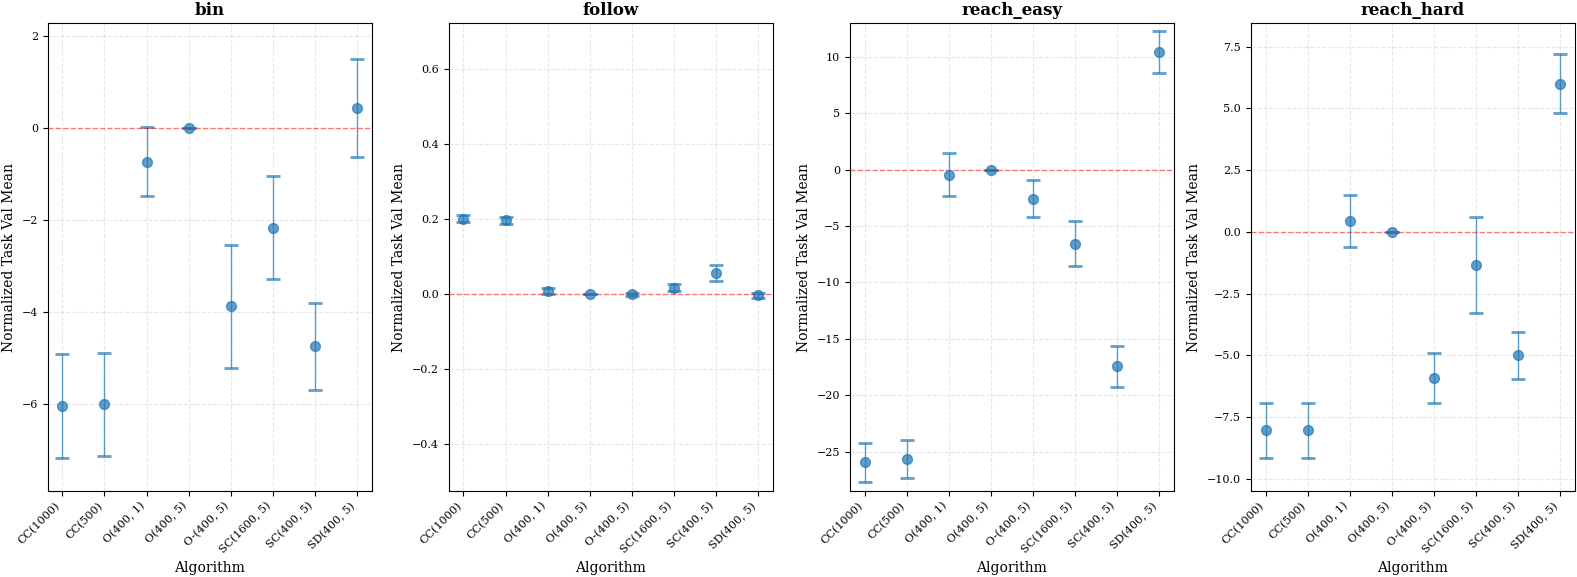

In [21]:
plot_algorithm_comparison_with_ci(df_plot)

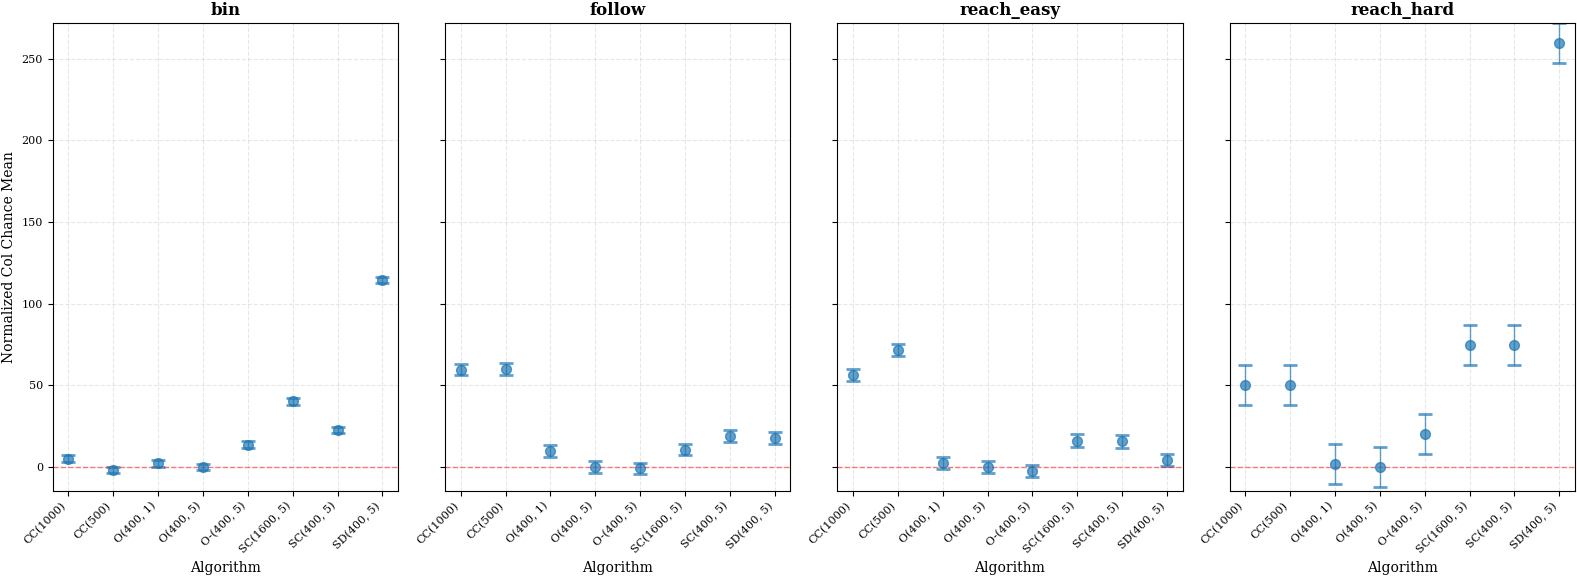

In [35]:
def plot_col_chance_comparison_with_ci(df, show_cols_as_chance_per_step, sim_step_num,confidence_level=0.95,fixed_y_limits_cols=True):
    """
    Create 4 subplots showing algorithm comparison for normalized_col_chance with confidence intervals.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: 'task_type', 'alg', 'normalized_col_chance_mean', 'baseline_col_chance_std', 'count'
    confidence_level : float
        Confidence level for the intervals (default 0.95 for 95% CI)
    show_cols_as_chance_per_step : bool
        If True, multiply values by 500 to show collision chance per step.
        If False, keep original normalized values.
    """
    # Get unique task types
    task_types = df['task_type'].unique()
    n_task_types = len(task_types)
    
    # Create subplots with shared y-axis
    fig, axes = plt.subplots(1, n_task_types, figsize=(4*n_task_types, 6), sharey=True)
    if n_task_types == 1:
        axes = [axes]
    
    # Calculate confidence interval multiplier (assuming normal distribution)
    z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_scores.get(confidence_level, 1.96)
    
    # First pass: collect all data to determine global y-axis limits
    all_means = []
    all_ci_half_widths = []
    
    for task_type in task_types:
        task_data = df[df['task_type'] == task_type].copy()
        task_data = task_data.sort_values('alg')
        
        means = task_data['normalized_col_chance_mean'].tolist()
        stds = task_data['baseline_col_chance_std'].tolist()
        counts = task_data['count'].tolist()
        
        # Apply scaling if requested
        if not show_cols_as_chance_per_step:
            means = [mean * sim_step_num for mean in means]
            stds = [std * sim_step_num for std in stds]
        
        ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(stds, counts)]
        
        all_means.extend(means)
        all_ci_half_widths.extend(ci_half_widths)
    
    # Calculate global y-axis limits
    global_y_min = min(all_means) - max(all_ci_half_widths) - 0.01
    global_y_max = max(all_means) + max(all_ci_half_widths) + 0.01
    
    # Second pass: create plots
    for i, task_type in enumerate(task_types):
        ax = axes[i]
        
        # Filter data for this task type
        task_data = df[df['task_type'] == task_type].copy()
        
        # Sort by algorithm name for consistent ordering
        task_data = task_data.sort_values('alg')
        
        # Get data
        algs = task_data['alg'].tolist()
        means = task_data['normalized_col_chance_mean'].tolist()
        stds = task_data['baseline_col_chance_std'].tolist()
        counts = task_data['count'].tolist()
        
        # Apply scaling if requested
        if not show_cols_as_chance_per_step:
            means = [mean * sim_step_num for mean in means]
            stds = [std * sim_step_num for std in stds]
        
        # Calculate confidence intervals
        ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(stds, counts)]
        
        # Create x positions
        x_pos = range(len(algs))
        
        # Plot points
        ax.scatter(x_pos, means, s=50, alpha=0.7, zorder=3)
        
        # Plot confidence intervals as error bars
        ax.errorbar(x_pos, means, yerr=ci_half_widths, 
                   fmt='none', capsize=5, capthick=2, 
                   alpha=0.7, zorder=2)
        
        # Customize subplot
        ax.set_title(f'{task_type}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Algorithm', fontsize=10)
        if i == 0:  # Only show y-label on the leftmost subplot
            y_label = 'Collision Chance per Step' if show_cols_as_chance_per_step else 'Normalized Col Chance Mean'
            ax.set_ylabel(y_label, fontsize=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(algs, rotation=45, ha='right')
        ax.grid(True, alpha=0.3)
        
        # Add horizontal line at y=0 for reference
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        
        # Set global y-axis limits
        if not fixed_y_limits_cols:
            ax.set_ylim(global_y_min, global_y_max)
        else:
            if show_cols_as_chance_per_step:
                ax.set_ylim(0, 1)
            else:
                ax.set_ylim(0, sim_step_num)
    plt.tight_layout()
    plt.show()

# Usage examples:
# Show collision chance per step (multiplied by 500)
# plot_col_chance_comparison_with_ci(df, show_cols_as_chance_per_step=True)

# Show normalized values (original behavior)
plot_col_chance_comparison_with_ci(df_plot, show_cols_as_chance_per_step=False,sim_step_num=500,fixed_y_limits_cols=False)

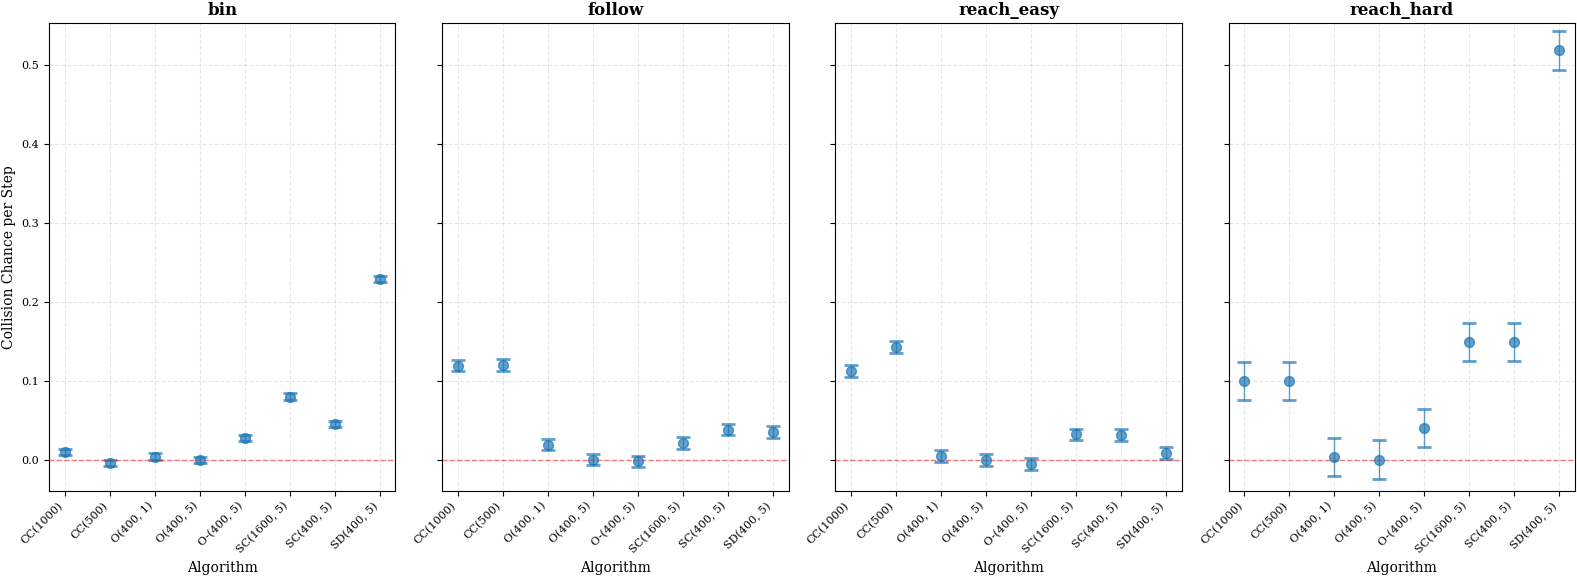

In [36]:
plot_col_chance_comparison_with_ci(df_plot, show_cols_as_chance_per_step=True,sim_step_num=500,fixed_y_limits_cols=False)

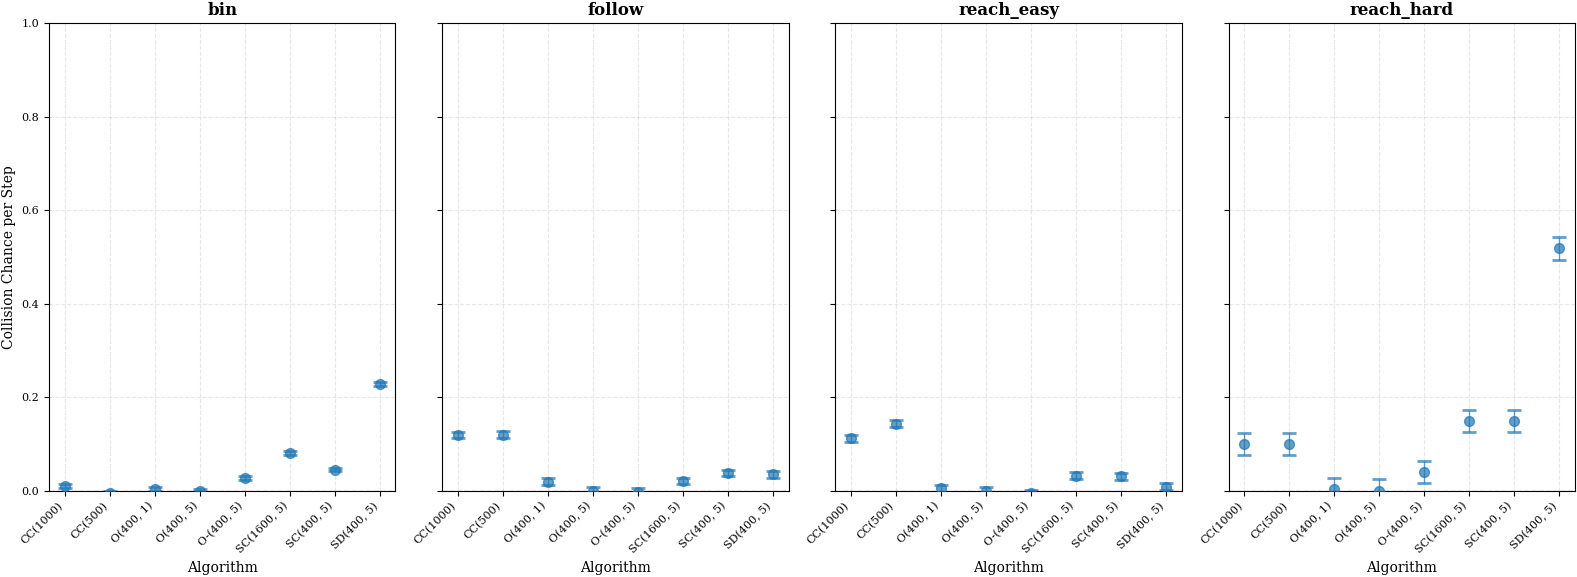

In [37]:
plot_col_chance_comparison_with_ci(df_plot, show_cols_as_chance_per_step=True,sim_step_num=500,fixed_y_limits_cols=True)

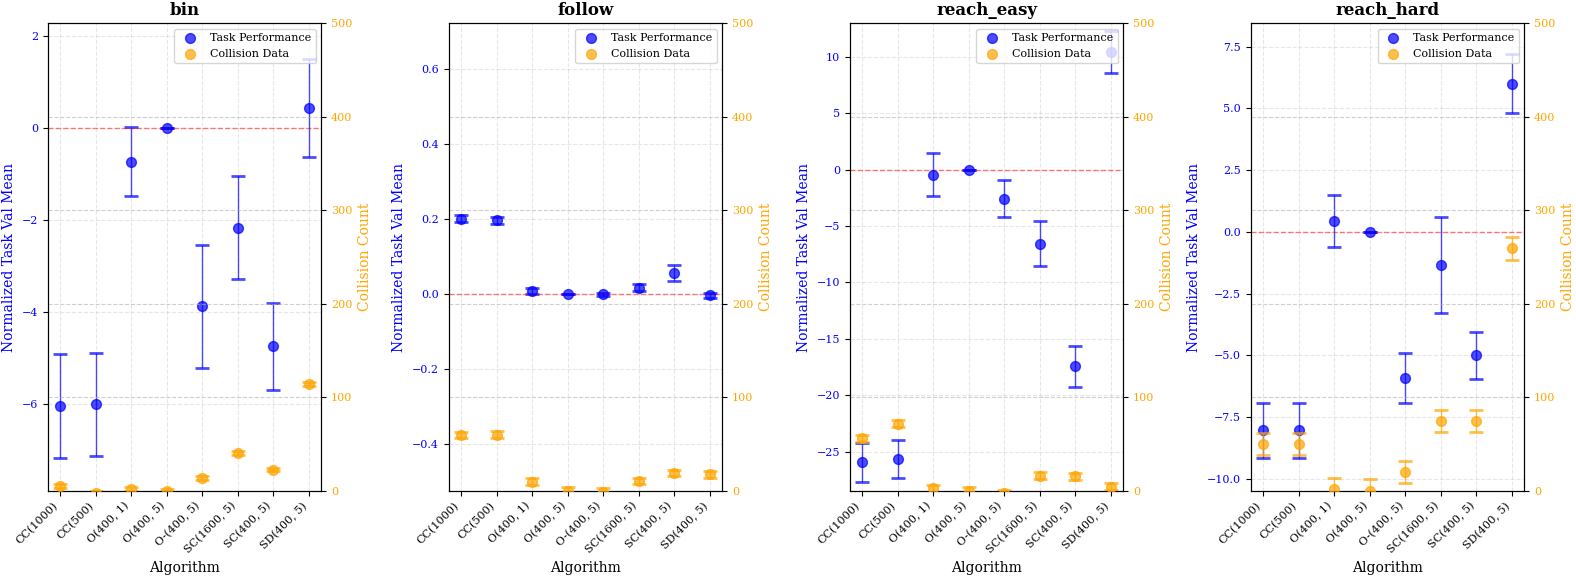

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_combined_algorithm_comparison_with_ci(df_task, df_col, confidence_level=0.95, 
                                            show_cols_as_chance_per_step=True, sim_step_num=500,
                                            fixed_y_limits_cols=True):
    """
    Create 4 subplots showing both task performance and collision data with dual y-axes.
    
    Parameters:
    -----------
    df_task : pandas.DataFrame
        DataFrame with task data: 'task_type', 'alg', 'normalized_task_val_mean', 'normalized_task_val_std', 'count'
    df_col : pandas.DataFrame
        DataFrame with collision data: 'task_type', 'alg', 'normalized_col_chance_mean', 'baseline_col_chance_std', 'count'
    confidence_level : float
        Confidence level for the intervals (default 0.95 for 95% CI)
    show_cols_as_chance_per_step : bool
        If True, multiply collision values by sim_step_num to show collision chance per step.
        If False, keep original normalized values.
    sim_step_num : int
        Number of simulation steps (default 500)
    fixed_y_limits_cols : bool
        Whether to use fixed y-axis limits for collision data
    """
    # Get unique task types
    task_types = df_task['task_type'].unique()
    n_task_types = len(task_types)
    
    # Create subplots
    fig, axes = plt.subplots(1, n_task_types, figsize=(4*n_task_types, 6))
    if n_task_types == 1:
        axes = [axes]
    
    # Calculate confidence interval multiplier
    z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_scores.get(confidence_level, 1.96)
    
    for i, task_type in enumerate(task_types):
        ax_left = axes[i]  # Left y-axis for task data
        
        # Filter task data for this task type
        task_data = df_task[df_task['task_type'] == task_type].copy()
        task_data = task_data.sort_values('alg')
        
        # Get task data
        algs = task_data['alg'].tolist()
        task_means = task_data['normalized_task_val_mean'].tolist()
        task_stds = task_data['normalized_task_val_std'].tolist()
        task_counts = task_data['count'].tolist()
        
        # Calculate task confidence intervals
        task_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(task_stds, task_counts)]
        
        # Create x positions
        x_pos = range(len(algs))
        
        # Plot task data on left y-axis
        ax_left.scatter(x_pos, task_means, s=50, alpha=0.7, zorder=3, color='blue', label='Task Performance')
        ax_left.errorbar(x_pos, task_means, yerr=task_ci_half_widths, 
                        fmt='none', capsize=5, capthick=2, 
                        alpha=0.7, zorder=2, color='blue')
        
        # Customize left y-axis
        ax_left.set_ylabel('Normalized Task Val Mean', fontsize=10, color='blue')
        ax_left.tick_params(axis='y', labelcolor='blue')
        
        # Add horizontal line at y=0 for task data
        ax_left.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        
        # Set task y-axis limits
        task_y_min = min(task_means) - max(task_ci_half_widths) - 0.5
        task_y_max = max(task_means) + max(task_ci_half_widths) + 0.5
        ax_left.set_ylim(task_y_min, task_y_max)
        
        # Create right y-axis for collision data
        ax_right = ax_left.twinx()
        
        # Filter collision data for this task type
        col_data = df_col[df_col['task_type'] == task_type].copy()
        col_data = col_data.sort_values('alg')
        
        # Get collision data
        col_means = col_data['normalized_col_chance_mean'].tolist()
        col_stds = col_data['baseline_col_chance_std'].tolist()
        col_counts = col_data['count'].tolist()
        
        # Apply scaling if requested
        if not show_cols_as_chance_per_step:
            col_means = [mean * sim_step_num for mean in col_means]
            col_stds = [std * sim_step_num for std in col_stds]
        
        # Calculate collision confidence intervals
        col_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(col_stds, col_counts)]
        
        # Plot collision data on right y-axis
        ax_right.scatter(x_pos, col_means, s=50, alpha=0.7, zorder=3, color='orange', label='Collision Data')
        ax_right.errorbar(x_pos, col_means, yerr=col_ci_half_widths, 
                         fmt='none', capsize=5, capthick=2, 
                         alpha=0.7, zorder=2, color='orange')
        
        # Customize right y-axis
        col_y_label = 'Collision Chance per Step' if show_cols_as_chance_per_step else 'Collision Count'
        ax_right.set_ylabel(col_y_label, fontsize=10, color='orange')
        ax_right.tick_params(axis='y', labelcolor='orange')
        
        # Set collision y-axis limits
        if fixed_y_limits_cols:
            if show_cols_as_chance_per_step:
                ax_right.set_ylim(0, 1)
            else:
                ax_right.set_ylim(0, sim_step_num)
        else:
            col_y_min = min(col_means) - max(col_ci_half_widths) - 0.01
            col_y_max = max(col_means) + max(col_ci_half_widths) + 0.01
            ax_right.set_ylim(col_y_min, col_y_max)
        
        # Customize subplot
        ax_left.set_title(f'{task_type}', fontsize=12, fontweight='bold')
        ax_left.set_xlabel('Algorithm', fontsize=10)
        ax_left.set_xticks(x_pos)
        ax_left.set_xticklabels(algs, rotation=45, ha='right')
        ax_left.grid(True, alpha=0.3)
        
        # Add legend
        lines1, labels1 = ax_left.get_legend_handles_labels()
        lines2, labels2 = ax_right.get_legend_handles_labels()
        ax_left.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Usage example:
plot_combined_algorithm_comparison_with_ci(df_plot, df_plot, 
                                         show_cols_as_chance_per_step=False, 
                                         sim_step_num=500, 
                                         fixed_y_limits_cols=True)

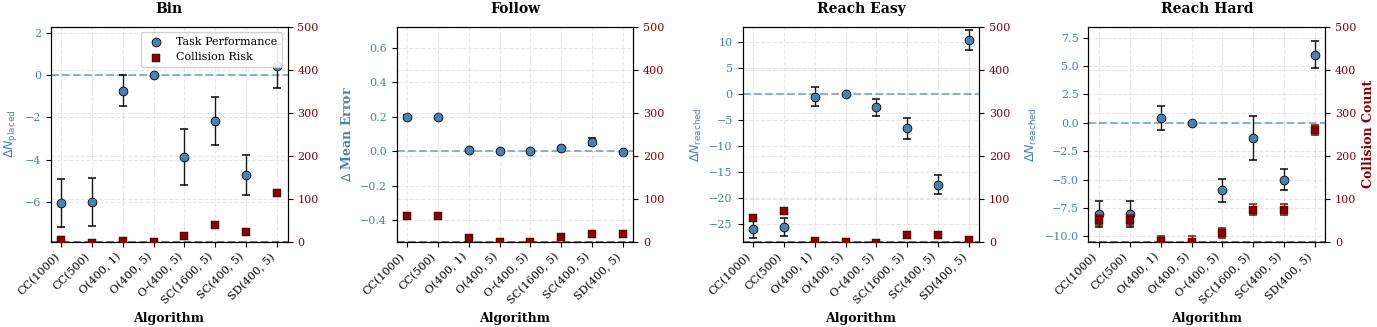

In [108]:
import matplotlib.pyplot as plt
import numpy as np

def plot_combined_algorithm_comparison_with_ci(df_task, df_col, confidence_level=0.95, 
                                            show_cols_as_chance_per_step=True, sim_step_num=500,
                                            fixed_y_limits_cols=True, save_path=None):
    """
    Create 4 subplots showing both task performance and collision data with dual y-axes.
    Styled for academic conference papers.
    """
    # Apply paper-ready style
    plt.rcParams.update({
        "figure.figsize": (14, 5.5),  # Wider for 4 subplots
        "font.size": 9,
        "font.family": "serif",
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "lines.linewidth": 1,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.3,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "savefig.format": "pdf"
    })
    
    # Get unique task types
    task_types = df_task['task_type'].unique()
    n_task_types = len(task_types)
    
    # Create subplots with proper spacing
    fig, axes = plt.subplots(1, n_task_types, figsize=(14, 3.5))
    if n_task_types == 1:
        axes = [axes]
    
    # Calculate confidence interval multiplier
    z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_scores.get(confidence_level, 1.96)
    
    # Define colors and markers for consistency
    task_color = 'steelblue'#'#1f77b4'  # Blue
    col_color = 'darkred'    
    task_marker = 'o'
    col_marker = 's'
    
    # Define task-specific y-labels
    task_y_labels = {
        'bin': r'$\Delta N_{\text{placed}}$',
        'reach_easy': r'$\Delta N_{\text{reached}}$',
        'reach_hard': r'$\Delta N_{\text{reached}}$',
        'follow': r'$\Delta$ Mean Error'
    }
    
    for i, task_type in enumerate(task_types):
        ax_left = axes[i]
        
        # Filter task data for this task type
        task_data = df_task[df_task['task_type'] == task_type].copy()
        task_data = task_data.sort_values('alg')
        
        # Get task data
        algs = task_data['alg'].tolist()
        task_means = task_data['normalized_task_val_mean'].tolist()
        task_stds = task_data['normalized_task_val_std'].tolist()
        task_counts = task_data['count'].tolist()
        
        # Calculate task confidence intervals
        task_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(task_stds, task_counts)]
        
        # Create x positions
        x_pos = range(len(algs))
        
        # Plot task data on left y-axis - SMALLER MARKERS
        ax_left.scatter(x_pos, task_means, s=40, alpha=1.0, zorder=4, 
                       color=task_color, marker=task_marker, edgecolors='black', linewidth=0.6,
                       label='Task Performance')
        ax_left.errorbar(x_pos, task_means, yerr=task_ci_half_widths, 
                        fmt='none', capsize=3, capthick=1.2, 
                        alpha=0.9, zorder=3, color='black', linewidth=1.0)
        
        # Customize left y-axis - TASK-SPECIFIC LABELS
        task_y_label = task_y_labels.get(task_type, 'Task Performance')
        ax_left.set_ylabel(task_y_label, fontsize=9, color='steelblue', fontweight='bold')
        ax_left.tick_params(axis='y', labelcolor=task_color, labelsize=8)
        
        # Add horizontal line at y=0 for task data (baseline) - TASK COLOR
        ax_left.axhline(y=0, color=task_color, linestyle='--', alpha=0.6, linewidth=1.5)
        
        # Set task y-axis limits
        task_y_min = min(task_means) - max(task_ci_half_widths) - 0.5
        task_y_max = max(task_means) + max(task_ci_half_widths) + 0.5
        ax_left.set_ylim(task_y_min, task_y_max)
        
        # Create right y-axis for collision data
        ax_right = ax_left.twinx()
        
        # Filter collision data for this task type
        col_data = df_col[df_col['task_type'] == task_type].copy()
        col_data = col_data.sort_values('alg')
        
        # Get collision data
        col_means = col_data['normalized_col_chance_mean'].tolist()
        col_stds = col_data['baseline_col_chance_std'].tolist()
        col_counts = col_data['count'].tolist()
        
        # Apply scaling if requested
        if not show_cols_as_chance_per_step:
            col_means = [mean * sim_step_num for mean in col_means]
            col_stds = [std * sim_step_num for std in col_stds]
        
        # Calculate collision confidence intervals
        col_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(col_stds, col_counts)]
        
        # Plot collision data on right y-axis - SMALLER MARKERS
        ax_right.scatter(x_pos, col_means, s=40, alpha=1.0, zorder=4, 
                        color=col_color, marker=col_marker, edgecolors='black', linewidth=0.3,
                        label='Collision Risk')
        ax_right.errorbar(x_pos, col_means, yerr=col_ci_half_widths, 
                         fmt='none', capsize=3, capthick=1.2, 
                         alpha=0.9, zorder=3, color=col_color, linewidth=1.0)
        
        # Add horizontal baseline line for collision data (O(400,5) value)
        # Find O(400,5) collision value for this task type
        o400_5_col_data = col_data[col_data['alg'] == 'O(400, 5)']
        if not o400_5_col_data.empty:
            o400_5_col_value = o400_5_col_data['normalized_col_chance_mean'].iloc[0]
            if not show_cols_as_chance_per_step:
                o400_5_col_value = o400_5_col_value * sim_step_num
            ax_right.axhline(y=o400_5_col_value, color=col_color, linestyle='--', alpha=0.6, linewidth=1.5)
        
        # Customize right y-axis - ONLY SHOW COLLISION LABEL ON RIGHTMOST SUBPLOT
        col_y_label = 'Collision Risk' if show_cols_as_chance_per_step else 'Collision Count'
        if i == n_task_types - 1:  # Only show on the last (rightmost) subplot
            ax_right.set_ylabel(col_y_label, fontsize=9, color=col_color, fontweight='bold')
        ax_right.tick_params(axis='y', labelcolor=col_color, labelsize=8)
        
        # Set collision y-axis limits
        if fixed_y_limits_cols:
            if show_cols_as_chance_per_step:
                ax_right.set_ylim(0, 1)
            else:
                ax_right.set_ylim(0, sim_step_num)
        else:
            col_y_min = min(col_means) - max(col_ci_half_widths) - 0.01
            col_y_max = max(col_means) + max(col_ci_half_widths) + 0.01
            ax_right.set_ylim(col_y_min, col_y_max)
        
        # Customize subplot
        ax_left.set_title(f'{task_type.replace("_", " ").title()}', fontsize=10, fontweight='bold', pad=10,color='black')
        ax_left.set_xlabel('Algorithm', fontsize=9, fontweight='bold')
        ax_left.set_xticks(x_pos)
        ax_left.set_xticklabels(algs, rotation=45, ha='right', fontsize=8)
        ax_left.grid(True, alpha=0.3, linestyle='--')
        
        # Add subtle legend only to the first subplot
        if i == 0:
            lines1, labels1 = ax_left.get_legend_handles_labels()
            lines2, labels2 = ax_right.get_legend_handles_labels()
            ax_left.legend(lines1 + lines2, labels1 + labels2, 
                          loc='upper right', fontsize=8, framealpha=0.9)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

plot_combined_algorithm_comparison_with_ci(df_plot, df_plot, 
                                         show_cols_as_chance_per_step=False, 
                                         sim_step_num=500, 
                                         fixed_y_limits_cols=True,
                                         save_path='combined_analysis.pdf')
